In [1]:
import torch
import numpy as np
import torch.nn.functional as F
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from einops import rearrange
from PIL import Image
import neuromaps.datasets
import nibabel as nib
import yaspy

import flat_mae.nisc as nisc

In [2]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [3]:
resampler = nisc.flat_resampler_fslr64k_224_560()

In [4]:
grads = []
for ii in range(1, 3):
    grad_l_path, grad_r_path = neuromaps.datasets.fetch_annotation(
        source="margulies2016", desc=f"fcgradient{ii:02d}", space="fsLR", den="32k"
    )
    grad_l = nib.load(grad_l_path).darrays[0].data
    grad_r = nib.load(grad_r_path).darrays[0].data
    grad = np.concatenate([grad_l, grad_r])
    grads.append(grad)

grads = np.stack(grads, axis=0)
print(grads.shape)

grads_flat = resampler.transform(grads)
print(grads_flat.shape)


[References] Please cite the following papers if you are using this data:

  For {'source': 'margulies2016', 'desc': 'fcgradient01', 'space': 'fsLR', 'den': '32k'}:
  [primary]:
    Daniel S Margulies, Satrajit S Ghosh, Alexandros Goulas, Marcel Falkiewicz, Julia M Huntenburg, Georg Langs, Gleb Bezgin, Simon B Eickhoff, F Xavier Castellanos, Michael Petrides, and others. Situating the default-mode network along a principal gradient of macroscale cortical organization. Proc Natl Acad Sci USA, 113(44):12574–12579, 2016.
  [secondary]:
    

[References] Please cite the following papers if you are using this data:

  For {'source': 'margulies2016', 'desc': 'fcgradient02', 'space': 'fsLR', 'den': '32k'}:
  [primary]:
    Daniel S Margulies, Satrajit S Ghosh, Alexandros Goulas, Marcel Falkiewicz, Julia M Huntenburg, Georg Langs, Gleb Bezgin, Simon B Eickhoff, F Xavier Castellanos, Michael Petrides, and others. Situating the default-mode network along a principal gradient of macroscale cort

In [5]:
surfaces = neuromaps.datasets.fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]

In [6]:
np.sum(grad == 0)

5572

2026-03-23 10:34:14.228 (   3.308s) [    71BBB1C0D740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD135: Permission denied

libEGL warning: failed to open /dev/dri/renderD135: Permission denied

libEGL warning: failed to open /dev/dri/card7: Permission denied

2026-03-23 10:34:14.689 (   3.769s) [    71BBB1C0D740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x624cdf80e700): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD134: Permission denied

libEGL warning: failed to open /dev/dri/renderD134: Permission denied

libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: failed to open /dev/dri/renderD133: Permission denied

libEGL warning: failed to open /dev/dri/renderD133: Permission denied

libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: failed to open /dev/dri/renderD132: Per

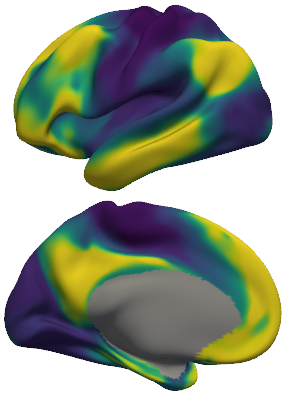

In [7]:
plotter_lh = yaspy.Plotter(surf_lh_path, hemi="lh", width=256)
plotter_rh = yaspy.Plotter(surf_rh_path, hemi="rh", width=256)

grad = grads[0]
grad_l, grad_r = np.split(grad, 2)

vmax = np.quantile(np.abs(grad), 0.9)
cmap = "viridis"

plotter_lh.overlay(
    np.where(grad_l != 0, grad_l, np.nan),
    cmap=cmap,
    vmin=-vmax,
    vmax=vmax,
)

plotter_rh.overlay(
    np.where(grad_r != 0, grad_r, np.nan),
    cmap=cmap,
    vmin=-vmax,
    vmax=vmax,
)

grad_img_l = yaspy.montage(
    [
        [plotter_lh.screenshot("lateral")],
        [plotter_lh.screenshot("medial")],
    ],
    pad=4,
)

grad_img_r = yaspy.montage(
    [
        [plotter_rh.screenshot("lateral")],
        [plotter_rh.screenshot("medial")],
    ],
    pad=4,
)

grad_img_l

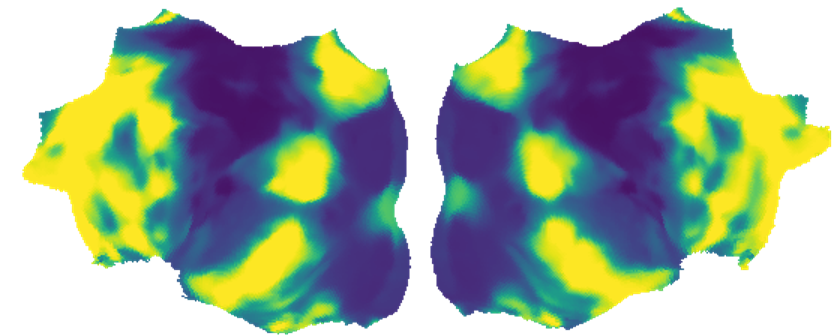

In [8]:
grad_flat = grads_flat[0]

H, W = grad_flat.shape

cmap = plt.get_cmap("viridis")
vmax = np.quantile(np.abs(grad), 0.9)
grad_flat = (grad_flat + vmax) / (2 * vmax)

grad_flat_img = cmap(np.where(resampler.mask_, grad_flat, np.nan))
grad_flat_img = Image.fromarray((255 * grad_flat_img).astype(np.uint8))

scale = 1.5
grad_flat_img = grad_flat_img.resize(
    (int(scale * W), int(scale * H)), resample=Image.Resampling.BICUBIC
)
grad_flat_img

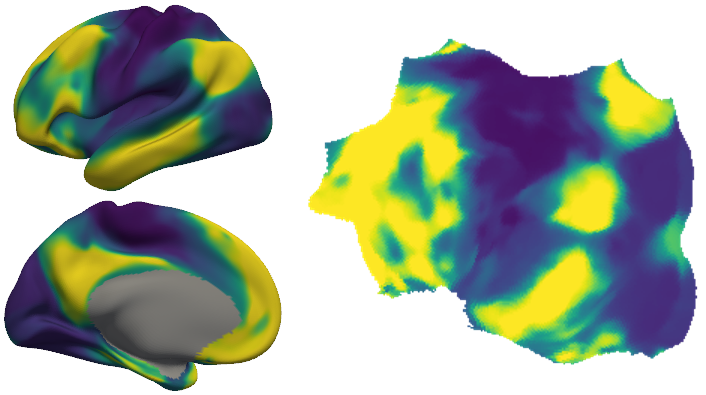

In [9]:
W_, H_ = grad_flat_img.size
yaspy.montage([grad_img_l, grad_flat_img.crop((0, 0, W_ // 2, H_))])

In [10]:
ckpt_path = "../data_scaling/output/data_scaling/n1600_1/pretrain/checkpoint-00004.pth"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
state = ckpt["model"]
print(ckpt["epoch"])

4


In [11]:
H, W = resampler.mask_.shape
patch_size = ckpt["args"]["patch_size"]
h = H // patch_size
w = W // patch_size
print(patch_size, (h, w))

16 (14, 35)


In [12]:
pos_embed = state["encoder.pos_embed.weight_spatial"]
print(pos_embed.shape)

pos_embed = pos_embed.reshape(h, w, -1).numpy()
print(pos_embed.shape)

torch.Size([1, 490, 768])
(14, 35, 768)


In [13]:
patch_mask = rearrange(resampler.mask_, "(h p) (w q) -> h w (p q)", p=patch_size, q=patch_size).any(
    axis=2
)
print(patch_mask.shape, patch_mask.sum())

(14, 35) 364


In [14]:
n_components = 2
components = np.zeros((h, w, n_components))

pca = PCA(n_components, whiten=True).fit(pos_embed[patch_mask])
components[patch_mask] = pca.transform(pos_embed[patch_mask])
print(components.shape)

(14, 35, 2)


In [15]:
components_flat = torch.from_numpy(components)
components_flat = components_flat.permute(2, 0, 1)[None]
components_flat = F.interpolate(components_flat, size=(H, W), mode="nearest")
components_flat = components_flat.squeeze(0).permute(1, 2, 0).numpy()
components_flat = components_flat * resampler.mask_[:, :, None]
print(components_flat.shape)

(224, 560, 2)


In [16]:
components_surf = resampler.inverse(components_flat.transpose(2, 0, 1))
print(components_surf.shape)

(2, 64984)


In [17]:
x = components_surf.T
y = grads.T

mask = (x[:, 0] != 0) & (y[:, 0] != 0)
x = x[mask]
y = y[mask]

b, *_ = np.linalg.lstsq(x, y, rcond=None)
print(b)
x = x @ b

x = (x - x.mean(axis=0)) / x.std(axis=0)
y = (y - y.mean(axis=0)) / y.std(axis=0)

dot = x.T @ y / len(x)
print(dot)

[[-2.94904713  0.96222957]
 [-1.39459258 -0.41103138]]
[[ 0.79260403 -0.30238865]
 [-0.46562594  0.50559376]]


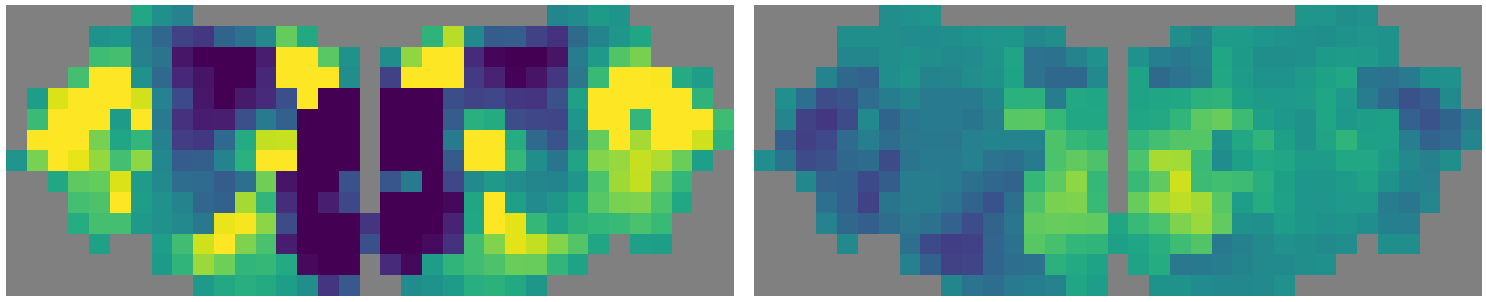

In [18]:
ploth = 1.0
plotw = (W / H) * ploth
nr = 1
nc = 2
f, axs = plt.subplots(nr, nc, figsize=(plotw * nc, ploth * nr))
axs = axs.flatten()

cmap = plt.get_cmap("viridis")
cmap.set_bad("gray")
vmax = np.quantile(np.abs(components @ b), 0.9)

for ii, ax in enumerate(axs):
    plt.sca(ax)
    plt.imshow(
        np.where(patch_mask, components @ b[:, ii], np.nan),
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="none",
    )
    plt.axis("off")

plt.tight_layout(pad=0.2)

libEGL warning: failed to open /dev/dri/renderD135: Permission denied

libEGL warning: failed to open /dev/dri/renderD135: Permission denied

libEGL warning: failed to open /dev/dri/card7: Permission denied

2026-03-23 10:34:20.302 (   9.382s) [    71BBB1C0D740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x624cdb7689c0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD134: Permission denied

libEGL warning: failed to open /dev/dri/renderD134: Permission denied

libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: failed to open /dev/dri/renderD133: Permission denied

libEGL warning: failed to open /dev/dri/renderD133: Permission denied

libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: failed to open /dev/dri/renderD132: Permission denied

libEGL warning: failed to open /dev/dri/renderD132: Permission denied

libEGL warning: failed to open /dev/d

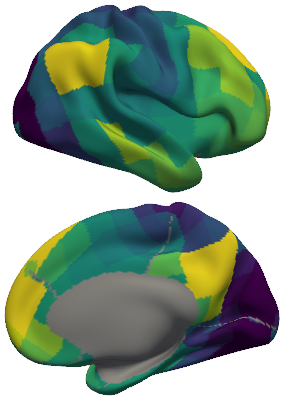

In [19]:
plotter_lh = yaspy.Plotter(surf_lh_path, hemi="lh", width=256)
plotter_rh = yaspy.Plotter(surf_rh_path, hemi="rh", width=256)

comp = b[:, 0] @ components_surf
comp_l, comp_r = np.split(comp, 2)

vmax = np.quantile(np.abs(comp), 0.9)
cmap = "viridis"

plotter_lh.overlay(
    np.where(comp_l != 0, comp_l, np.nan),
    cmap=cmap,
    vmin=-vmax,
    vmax=vmax,
)

plotter_rh.overlay(
    np.where(comp_r != 0, comp_r, np.nan),
    cmap=cmap,
    vmin=-vmax,
    vmax=vmax,
)

comp_img_l = yaspy.montage(
    [
        [plotter_lh.screenshot("lateral")],
        [plotter_lh.screenshot("medial")],
    ],
    pad=4,
)

comp_img_r = yaspy.montage(
    [
        [plotter_rh.screenshot("lateral")],
        [plotter_rh.screenshot("medial")],
    ],
    pad=4,
)

comp_img_r

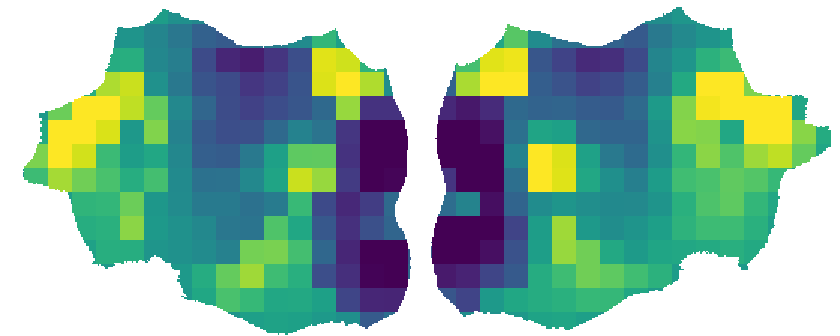

In [20]:
comp_flat = components_flat @ b[:, 0]

H, W = comp_flat.shape

cmap = plt.get_cmap("viridis")
vmax = np.quantile(np.abs(grad), 0.9)
comp_flat = (comp_flat + vmax) / (2 * vmax)

comp_flat_img = cmap(np.where(resampler.mask_, comp_flat, np.nan))
comp_flat_img = Image.fromarray((255 * comp_flat_img).astype(np.uint8))

scale = 1.5
comp_flat_img = comp_flat_img.resize(
    (int(scale * W), int(scale * H)), resample=Image.Resampling.NEAREST
)
comp_flat_img

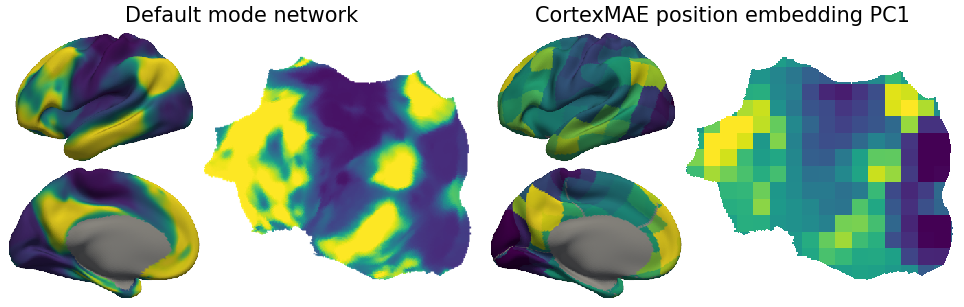

In [27]:
W_, H_ = grad_flat_img.size
panel_l = yaspy.montage(
    [
        grad_img_l,
        grad_flat_img.crop((20, 0, W_ // 2, H_)),
    ]
)
# panel_r = yaspy.montage(
#     [
#         comp_flat_img.crop((W_ // 2, 0, W_ - 20, H_)),
#         comp_img_r,
#     ]
# )
panel_r = yaspy.montage(
    [
        comp_img_l,
        comp_flat_img.crop((20, 0, W_ // 2, H_)),
    ]
)

W_, H_ = panel_l.size

figw = PLOTW
figh = 1.2 * (H_ / (2 * W_)) * figw

f, axs = plt.subplots(1, 2, figsize=(figw, figh))

plt.sca(axs[0])
plt.imshow(panel_l, interpolation="none")
plt.axis("off")
plt.title("Default mode network", fontsize=5)

plt.sca(axs[1])
plt.imshow(panel_r, interpolation="none")
plt.axis("off")
plt.title("CortexMAE position embedding PC1", fontsize=5)

plt.tight_layout(pad=0.5)

f.savefig("results/pos_embed.pdf")

In [31]:
def load_pos_embed(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    state = ckpt["model"]
    patch_size = ckpt["args"]["patch_size"]
    h = H // patch_size
    w = W // patch_size
    pos_embed = state["encoder.pos_embed.weight_spatial"]
    pos_embed = pos_embed.reshape(h, w, -1).numpy()
    return pos_embed

In [34]:
def get_pos_embed_comps(pos_embed, resampler, patch_mask, n_components=2):
    h, w, _ = pos_embed.shape
    components = np.zeros((h, w, n_components))
    pca = PCA(n_components, whiten=True).fit(pos_embed[patch_mask])
    components[patch_mask] = pca.transform(pos_embed[patch_mask])
    components_flat = torch.from_numpy(components)
    components_flat = components_flat.permute(2, 0, 1)[None]
    components_flat = F.interpolate(components_flat, size=(H, W), mode="nearest")
    components_flat = components_flat.squeeze(0).permute(1, 2, 0).numpy()
    components_flat = components_flat * resampler.mask_[:, :, None]
    components_surf = resampler.inverse(components_flat.transpose(2, 0, 1))
    return components, components_flat, components_surf

In [33]:
def align_comps(x, y):
    mask = (x[:, 0] != 0) & (y[:, 0] != 0)
    x = x[mask]
    y = y[mask]
    b, *_ = np.linalg.lstsq(x, y, rcond=None)
    x = x @ b
    x = (x - x.mean(axis=0)) / x.std(axis=0)
    y = (y - y.mean(axis=0)) / y.std(axis=0)
    dot = x.T @ y / len(x)
    return b, dot

In [ ]:
epochs = [4, 9, 19, 39, 79]

figw = 2 * PLOTW + 0.25
ncol = len(epochs + 1)